Transfer learning on a custom DenseNet model for Euro SAT dataset: https://www.tensorflow.org/datasets/catalog/eurosat

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np

In [3]:
import warnings
warnings.filterwarnings('ignore')

Data Preprocessing- remove null values, convert the categorical data to numerical values

In [4]:
import matplotlib.pyplot as plt
from datasets import load_dataset

ds = load_dataset("tanganke/eurosat", split="train")

total = len(ds)
split = int(total * 0.8)

NUM_CLASSES = 10

X = np.zeros((total, 224, 224, 3), dtype=np.float32)
y = np.zeros((total, NUM_CLASSES), dtype=np.float32)

for i in range(total):
    img = tf.image.resize(tf.cast(np.array(ds[i]["image"]), tf.float32), (224, 224))
    X[i] = img / 255.0  # ← normalisation
    y[i] = tf.one_hot(ds[i]["label"], NUM_CLASSES)
    if i % 10000 == 0:
        print(f"{i}/{total} loaded...")

# Shuffle before splitting
np.random.seed(42)
indices = np.random.permutation(total)

X = X[indices]
y = y[indices]

# Then split
X_train, y_train = X[:split], y[:split]
X_val,   y_val   = X[split:], y[split:]

# Verify val has all classes
print("Val class distribution:", np.argmax(y_val, axis=1))
import collections
print(collections.Counter(np.argmax(y_val, axis=1).tolist()))

print("Done!", X_train.shape, X_val.shape)

README.md:   0%|          | 0.00/5.01k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/73.5M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/9.13M [00:00<?, ?B/s]

data/contrast-00000-of-00001.parquet:   0%|          | 0.00/1.41M [00:00<?, ?B/s]

data/gaussian_noise-00000-of-00001.parqu(…):   0%|          | 0.00/3.38M [00:00<?, ?B/s]

...

Generating jpeg_compression split:   0%|          | 0/2700 [00:00<?, ? examples/s]

Generating motion_blur split:   0%|          | 0/2700 [00:00<?, ? examples/s]

Generating pixelate split:   0%|          | 0/2700 [00:00<?, ? examples/s]

Generating spatter split:   0%|          | 0/2700 [00:00<?, ? examples/s]

0/21600 loaded...
10000/21600 loaded...
20000/21600 loaded...
Val class distribution: [3 0 8 ... 2 0 7]
Counter({9: 534, 2: 494, 0: 479, 7: 467, 1: 462, 6: 395, 8: 394, 4: 393, 3: 364, 5: 338})
Done! (17280, 224, 224, 3) (4320, 224, 224, 3)


In [5]:
# Class names
print(ds.features["label"].names)

['annual crop land', 'forest', 'brushland or shrubland', 'highway or road', 'industrial buildings or commercial buildings', 'pasture land', 'permanent crop land', 'residential buildings or homes or apartments', 'river', 'lake or sea']


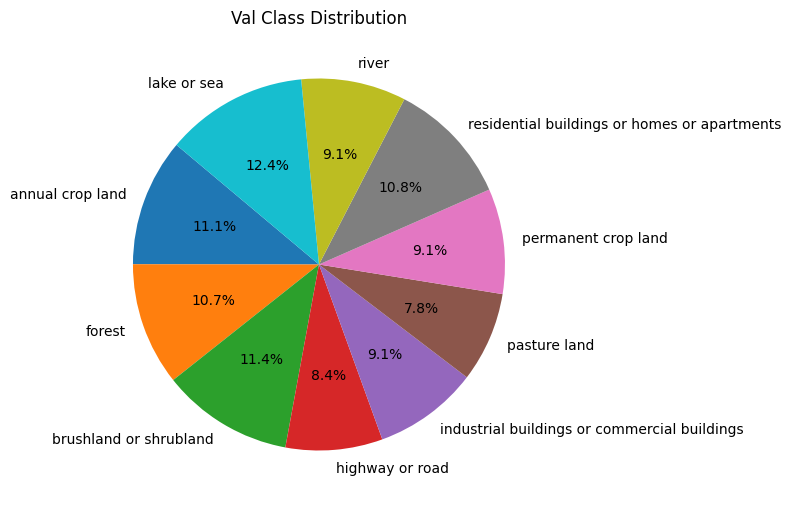

In [6]:
import matplotlib.pyplot as plt

class_names = ds.features["label"].names
counts = collections.Counter(np.argmax(y_val, axis=1).tolist())
values = [counts[i] for i in range(NUM_CLASSES)]

plt.figure(figsize=(6, 7))
plt.pie(values, labels=class_names, autopct='%1.1f%%', startangle=140)
plt.title("Val Class Distribution")
plt.show()

Training the data on DenseNet201 model, Using GlobalAveragePooling to avoid any overfitting on EuroSAT as it's a relatively small dataset

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=20,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

In [8]:
num_classes = 10
IMG_SIZE = (224, 224)

base_model = tf.keras.applications.DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=IMG_SIZE + (3,)   # can modify for different datasets based on the size
)

base_model.trainable = False

model = tf.keras.Sequential()
model.add(base_model)

 # Using GlobalAveragePooling instead of Flatten
model.add(tf.keras.layers.GlobalAveragePooling2D())
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(units=256, activation='relu'))
model.add(tf.keras.layers.Dropout(0.5))

model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(units=128, activation='relu'))
model.add(tf.keras.layers.Dropout(0.4))

model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(units=64, activation='relu'))

model.add(tf.keras.layers.Dense(units=num_classes, activation='softmax'))

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [9]:
model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    metrics=['accuracy']
)

datagen.fit(X_train)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=10,
    steps_per_epoch=len(X_train) // 32,
    validation_data=(X_val, y_val)
)

Epoch 1/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 218s 348ms/step - accuracy: 0.4524 - loss: 1.6502 - val_accuracy: 0.7961 - val_loss: 0.7844
Epoch 2/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 175s 324ms/step - accuracy: 0.7008 - loss: 0.9312 - val_accuracy: 0.8662 - val_loss: 0.4422
Epoch 3/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 172s 319ms/step - accuracy: 0.7760 - loss: 0.6939 - val_accuracy: 0.8921 - val_loss: 0.3299
Epoch 4/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 170s 315ms/step - accuracy: 0.8133 - loss: 0.5806 - val_accuracy: 0.9069 - val_loss: 0.2739
Epoch 5/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 171s 317ms/step - accuracy: 0.8336 - loss: 0.5116 - val_accuracy: 0.9167 - val_loss: 0.2461
Epoch 6/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 172s 319ms/step - accuracy: 0.8444 - loss: 0.4751 - val_accuracy: 0.9204 - val_loss: 0.2291
Epoch 7/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 172s 319ms/step - accuracy: 0.8558 - loss: 0.4447 - val_accuracy: 0.9273 - val_loss: 0.2135
Epoch 8/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 172s 318ms/step - accuracy: 0.8672 -

In [10]:
model.save('/content/drive/MyDrive/Dense121_base_model.keras')
print("Model Saved!")

Model Saved!


In [12]:
print("X_train range:", X_train.min(), "to", X_train.max())
print("X_val range:  ", X_val.min(),   "to", X_val.max())
print("X_train shape:", X_train.shape)
print("X_val shape:  ", X_val.shape)
print("y_val sample: ", y_val[0])

# Check what model predicts on val
sample_pred = model.predict(X_val[:32])
print("Pred shape:", sample_pred.shape)
print("Pred sample:", sample_pred[0])
print("Pred argmax:", np.argmax(sample_pred[0]))
print("True argmax:", np.argmax(y_val[0]))

X_train range: 0.05126096 to 1.0
X_val range:   0.06452581 to 1.0
X_train shape: (17280, 224, 224, 3)
X_val shape:   (4320, 224, 224, 3)
y_val sample:  [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Pred shape: (32, 10)
Pred sample: [1.52274163e-03 1.13877388e-04 6.36071141e-04 9.75425422e-01
 4.05187858e-03 2.34365324e-03 2.52034981e-03 6.87243883e-04
 1.26395365e-02 5.93567784e-05]
Pred argmax: 3
True argmax: 3


In [11]:
modelloss, modelaccuracy = model.evaluate(X_val, y_val)
print("Test Loss: ", modelloss)
print("Test Accuracy: ", modelaccuracy)

135/135 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - accuracy: 0.9331 - loss: 0.1910
Test Loss:  0.1910375952720642
Test Accuracy:  0.9331018328666687


135/135 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step


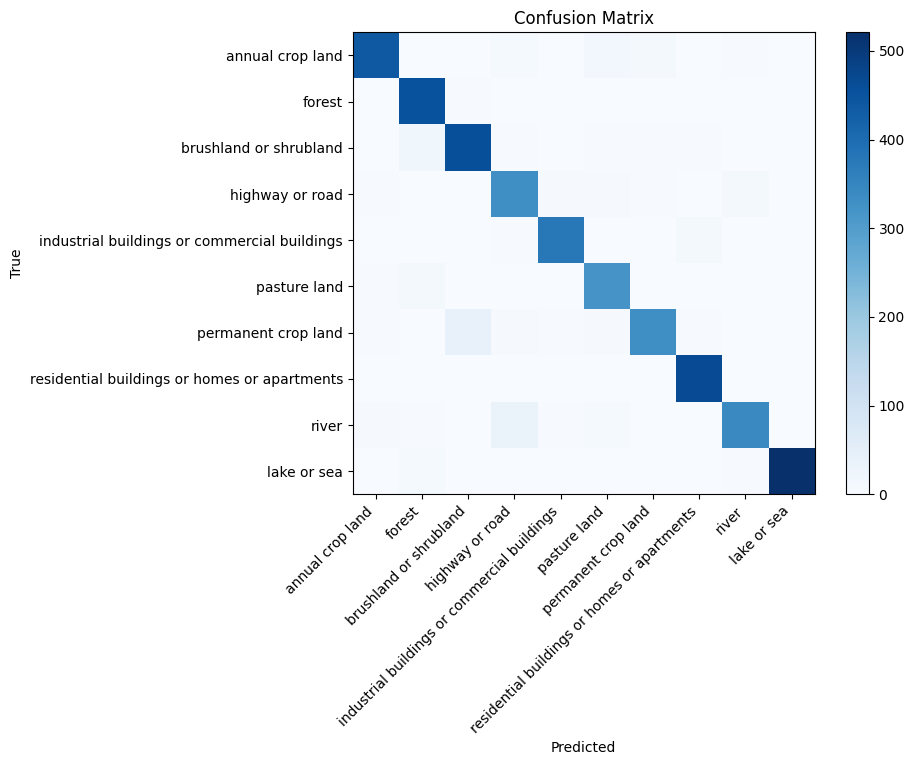

In [13]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

y_pred = np.argmax(model.predict(X_val), axis=1)
y_true = np.argmax(y_val, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks(range(NUM_CLASSES), ds.features["label"].names, rotation=45, ha='right')
plt.yticks(range(NUM_CLASSES), ds.features["label"].names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

Test the prediction against the actual images to see the different categories that were predicted correctly and the ones which were not

135/135 ━━━━━━━━━━━━━━━━━━━━ 22s 76ms/step


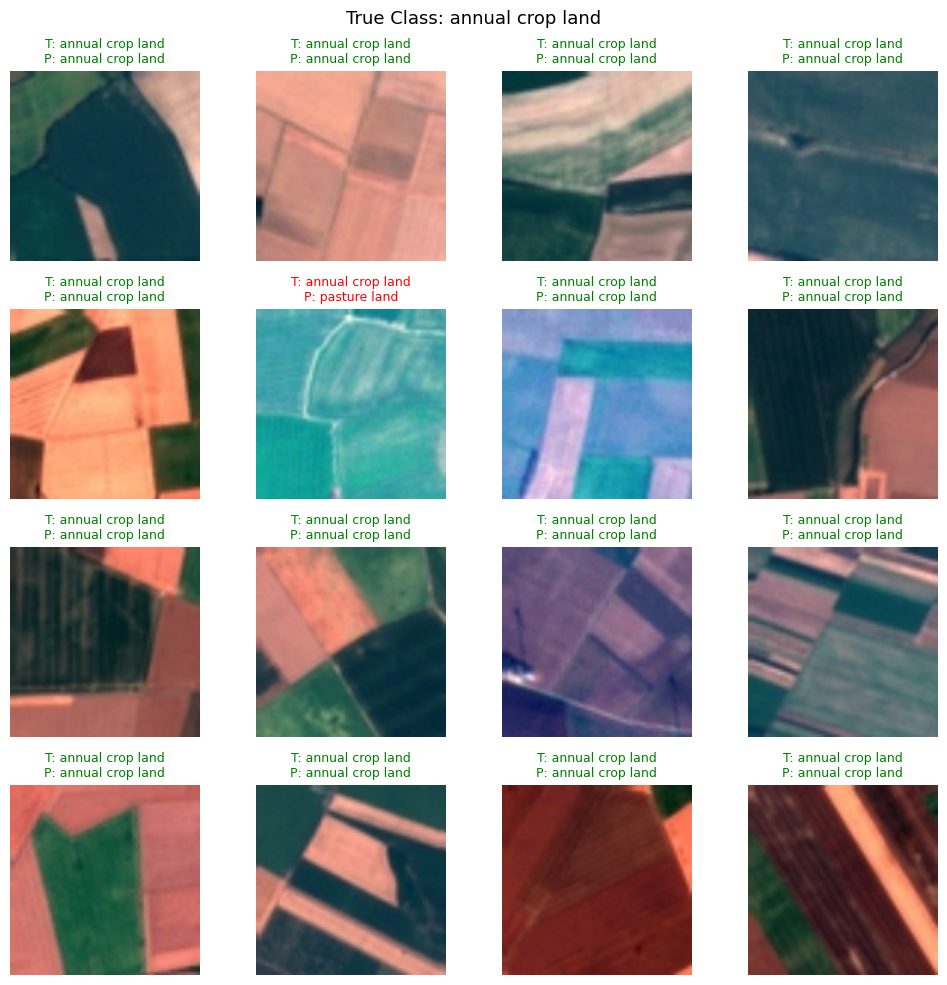

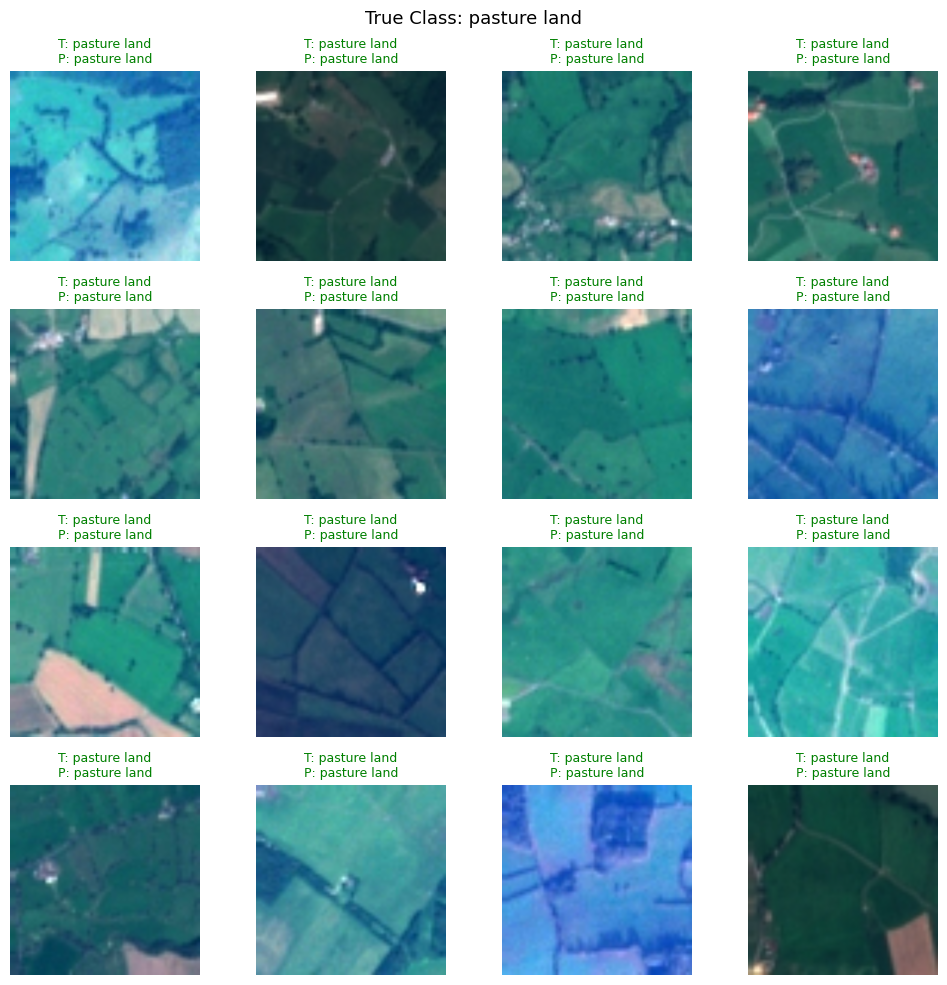

In [17]:
def plot_class_predictions(x_test_images, y_true, y_pred, class_names,
                            target_class=3, n=16):

    # Get samples of a specific true class
    class_idx = np.where(y_true == target_class)[0]
    # Handle cases where there are fewer samples than n
    if len(class_idx) < n:
        n = len(class_idx)
    if n == 0:
        print(f"No samples found for class {class_names[target_class]} to plot.")
        return

    indices = np.random.choice(class_idx, n, replace=False)

    plt.figure(figsize=(10, 10))
    for i, idx in enumerate(indices):
        plt.subplot(4, 4, i + 1)

        # Get the image and normalize for display [0, 1]
        img = x_test_images[idx]
        # Rescale values to [0, 1] for imshow, as preprocess_input can output values outside this range
        img_display = (img - img.min()) / (img.max() - img.min() + 1e-7)
        plt.imshow(img_display)
        plt.axis('off')

        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred[idx]]
        correct = y_true[idx] == y_pred[idx]

        color = 'green' if correct else 'red'
        plt.title(f'T: {true_label}\nP: {pred_label}',
                  color=color, fontsize=9)

    plt.suptitle(f'True Class: {class_names[target_class]}', fontsize=13)
    plt.tight_layout()
    plt.show()

# Recalculate y_true to get integer labels from y_test (one-hot encoded)

class_names = ds.features["label"].names

y_true_b = np.argmax(y_val, axis=1)
y_pred_b = np.argmax(model.predict(X_val), axis=1)

plot_class_predictions(X_val, y_true_b, y_pred_b, class_names, target_class=0)
plot_class_predictions(X_val, y_true_b, y_pred_b, class_names, target_class=5)

Fine-tuning by unfreezing top layers and seeing if the weights help in the accuracy

In [14]:
# Unfreeze last 50 layers
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

# Recompile with lower LR
model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # 10x lower
    metrics=['accuracy']
)

# Fine-tune
history_finetune = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=5,
    steps_per_epoch=len(X_train) // 32,
    validation_data=(X_val, y_val)
)


Epoch 1/5
540/540 ━━━━━━━━━━━━━━━━━━━━ 231s 355ms/step - accuracy: 0.8813 - loss: 0.3667 - val_accuracy: 0.9352 - val_loss: 0.1882
Epoch 2/5
540/540 ━━━━━━━━━━━━━━━━━━━━ 175s 324ms/step - accuracy: 0.8865 - loss: 0.3525 - val_accuracy: 0.9377 - val_loss: 0.1825
Epoch 3/5
540/540 ━━━━━━━━━━━━━━━━━━━━ 173s 321ms/step - accuracy: 0.8841 - loss: 0.3525 - val_accuracy: 0.9396 - val_loss: 0.1799
Epoch 4/5
540/540 ━━━━━━━━━━━━━━━━━━━━ 174s 323ms/step - accuracy: 0.8922 - loss: 0.3412 - val_accuracy: 0.9417 - val_loss: 0.1727
Epoch 5/5
540/540 ━━━━━━━━━━━━━━━━━━━━ 175s 324ms/step - accuracy: 0.8935 - loss: 0.3280 - val_accuracy: 0.9410 - val_loss: 0.1728


In [ ]:
# Save fine-tuned model
model.save('/content/drive/MyDrive/finetuned_model.keras')

                           Loss   Accuracy
Base Model               0.1910     0.9331
Fine-tuned Model         0.1728     0.9410
Improvement              0.0182     0.0079


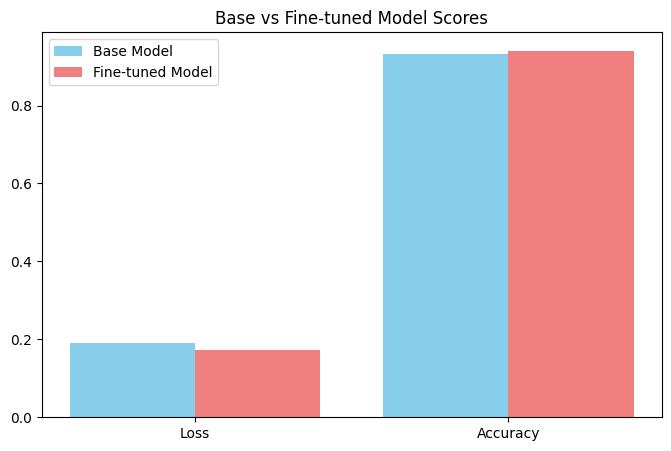

In [16]:
finetune_loss, finetune_acc = model.evaluate(X_val, y_val, verbose=0)
base_loss, base_acc = modelloss, modelaccuracy

# Print comparison
print(f"{'':20} {'Loss':>10} {'Accuracy':>10}")
print(f"{'Base Model':20} {base_loss:>10.4f} {base_acc:>10.4f}")
print(f"{'Fine-tuned Model':20} {finetune_loss:>10.4f} {finetune_acc:>10.4f}")
print(f"{'Improvement':20} {base_loss-finetune_loss:>10.4f} {finetune_acc-base_acc:>10.4f}")

# Plot comparison
import matplotlib.pyplot as plt

metrics   = ['Loss', 'Accuracy']
base      = [base_loss, base_acc]
finetuned = [finetune_loss, finetune_acc]

x = range(len(metrics))
plt.figure(figsize=(8, 5))
plt.bar([i - 0.2 for i in x], base,      width=0.4, label='Base Model', color='skyblue')
plt.bar([i + 0.2 for i in x], finetuned, width=0.4, label='Fine-tuned Model', color='lightcoral')
plt.xticks(x, metrics)
plt.title("Base vs Fine-tuned Model Scores")
plt.legend()
plt.show()